Numerical test of the exact SSR representation formula of Theorem 2 in Fukasawa (2026), "[On the Skew Stickiness Ratio](https://arxiv.org/abs/2602.05241v2)", for the two-factor Bergomi and rough Bergomi models (Remark 1).

Unlike the finite-difference `ssr_all`, `ssr_fukasawa_all` estimates `R_0 = X_0 / Y_0` from a single, un-bumped Monte Carlo simulation, using the kernel-weighted integrals of Theorem 2. This notebook checks that both estimators agree.

## Fukasawa SSR estimator

For $N$ simulated paths, let $\widehat F=N^{-1}\sum_j S_T^{(j)}$ and
$\widehat d_2=-\widehat\sigma_{\mathrm{ATM}}\sqrt T/2$, where
$\widehat\sigma_{\mathrm{ATM}}$ is the implied volatility of the Monte Carlo
call price at strike $\widehat F$. Define

$$
Q_j=\int_0^T k(t)\sqrt{V_t^{(j)}}\,dW_t^{(j)}
-\int_0^T k(t)V_t^{(j)}\,dt.
$$

The estimator returned by `ssr_fukasawa_all` is

$$
\widehat R_0=\frac{\widehat X_0}{\widehat Y_0},\qquad
\widehat X_0=-\frac{\sum_{j=1}^N
\mathbf 1_{\{S_T^{(j)}<\widehat F\}}S_T^{(j)}Q_j}
{2N\widehat F\sqrt{\xi_0(0)}},\qquad
\widehat Y_0=\Phi(\widehat d_2)-\frac1N\sum_{j=1}^N
\mathbf 1_{\{S_T^{(j)}\geq\widehat F\}}.
$$

Here $V_t=\xi_t(t)$, $W$ drives the spot, $\Phi$ is the standard normal CDF,
and the model kernels are

$$
k(t)=
\begin{cases}
w\alpha\big[(1-\theta)\rho_{S1}e^{-k_1t}+\theta\rho_{S2}e^{-k_2t}\big],
&\text{two-factor Bergomi},\\
\rho\eta\sqrt{2H}\,t^{H-1/2},&\text{rough Bergomi}.
\end{cases}
$$

Both expectations use the same unperturbed paths; $\widehat Y_0\ne0$ is required.


**Time discretization.** On $t_i=i\Delta t$, $\Delta t=T/m$, write
$Q_j\approx J_j-L_j$. Two-factor Bergomi uses all intervals with a
left-point stochastic integral and trapezoidal drift:

$$
J_j=\sum_{i=0}^{m-1}k(t_i)\sqrt{V_{t_i}^{(j)}}\,\Delta W_i^{(j)},\qquad
L_j=\frac{\Delta t}{2}\sum_{i=0}^{m-1}
\left[k(t_i)V_{t_i}^{(j)}+k(t_{i+1})V_{t_{i+1}}^{(j)}\right].
$$

Rough Bergomi omits the first stochastic interval and uses right-point drift:

$$
J_j=\sum_{i=1}^{m-1}k(t_i)\sqrt{V_{t_i}^{(j)}}\,\Delta W_i^{(j)},\qquad
L_j=\Delta t\sum_{i=0}^{m-1}k(t_{i+1})V_{t_{i+1}}^{(j)}.
$$

For rough Bergomi with $H<1/2$, $k(t)$ diverges at zero. Omitting
$[0,\Delta t]$ avoids evaluating $k(0)$.

# Imports

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from ssr.rough_bergomi import RoughBergomiModel, get_params_rough_bergomi
from ssr.two_bergomi import TwoFactorBergomiModel, get_params_two_factor_bergomi
import seaborn as sns

sns.set_theme(context="talk", style="whitegrid")

SEED = 1234
N_MC = 300_000
N_BATCH = 1

# Two-factor Bergomi

In [5]:
Ts = np.linspace(0.1, 3.0, 15)

In [22]:
id = 2
params, xi0 = get_params_two_factor_bergomi(id)
n_disc = 300
two_bergomi = TwoFactorBergomiModel(params=params, xi0=xi0)
two_bergomi

TwoFactorBergomiModel with parameters:
w=3.48, k1=5.25, k2=0.28, theta=0.245, rho12=0.0, rhoS1=-0.35, rhoS2=-0.83, s0=1.0

In [23]:
ssr_fd = two_bergomi.ssr_all(
    T=Ts, n_mc=N_MC, n_disc=n_disc, eps_ssr=1e-4, n_quad=40, n_batch=N_BATCH, seed=SEED
)


Computing SSR:
----------------
Model: TwoFactorBergomiModel
Parameters:
Maturity T:  [0.1        0.30714286 0.51428571 0.72142857 0.92857143 1.13571429
 1.34285714 1.55       1.75714286 1.96428571 2.17142857 2.37857143
 2.58571429 2.79285714 3.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.0001
Number of simulation loops: 1
Number of independent batches: 1

1/15: expiry 0.1000
2/15: expiry 0.3071
3/15: expiry 0.5143
4/15: expiry 0.7214
5/15: expiry 0.9286
6/15: expiry 1.1357
7/15: expiry 1.3429
8/15: expiry 1.5500
9/15: expiry 1.7571
10/15: expiry 1.9643
11/15: expiry 2.1714
12/15: expiry 2.3786
13/15: expiry 2.5857
14/15: expiry 2.7929
15/15: expiry 3.0000


In [24]:
ssr_fukasawa = two_bergomi.ssr_fukasawa_all(
    T=Ts, n_mc=N_MC, n_disc=n_disc, n_batch=N_BATCH, seed=SEED
)


Computing Fukasawa SSR:
----------------
Model: TwoFactorBergomiModel
Maturity T:  [0.1        0.30714286 0.51428571 0.72142857 0.92857143 1.13571429
 1.34285714 1.55       1.75714286 1.96428571 2.17142857 2.37857143
 2.58571429 2.79285714 3.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Number of simulation loops: 1
Number of independent batches: 1

1/15: expiry 0.1000
2/15: expiry 0.3071
3/15: expiry 0.5143
4/15: expiry 0.7214
5/15: expiry 0.9286
6/15: expiry 1.1357
7/15: expiry 1.3429
8/15: expiry 1.5500
9/15: expiry 1.7571
10/15: expiry 1.9643
11/15: expiry 2.1714
12/15: expiry 2.3786
13/15: expiry 2.5857
14/15: expiry 2.7929
15/15: expiry 3.0000


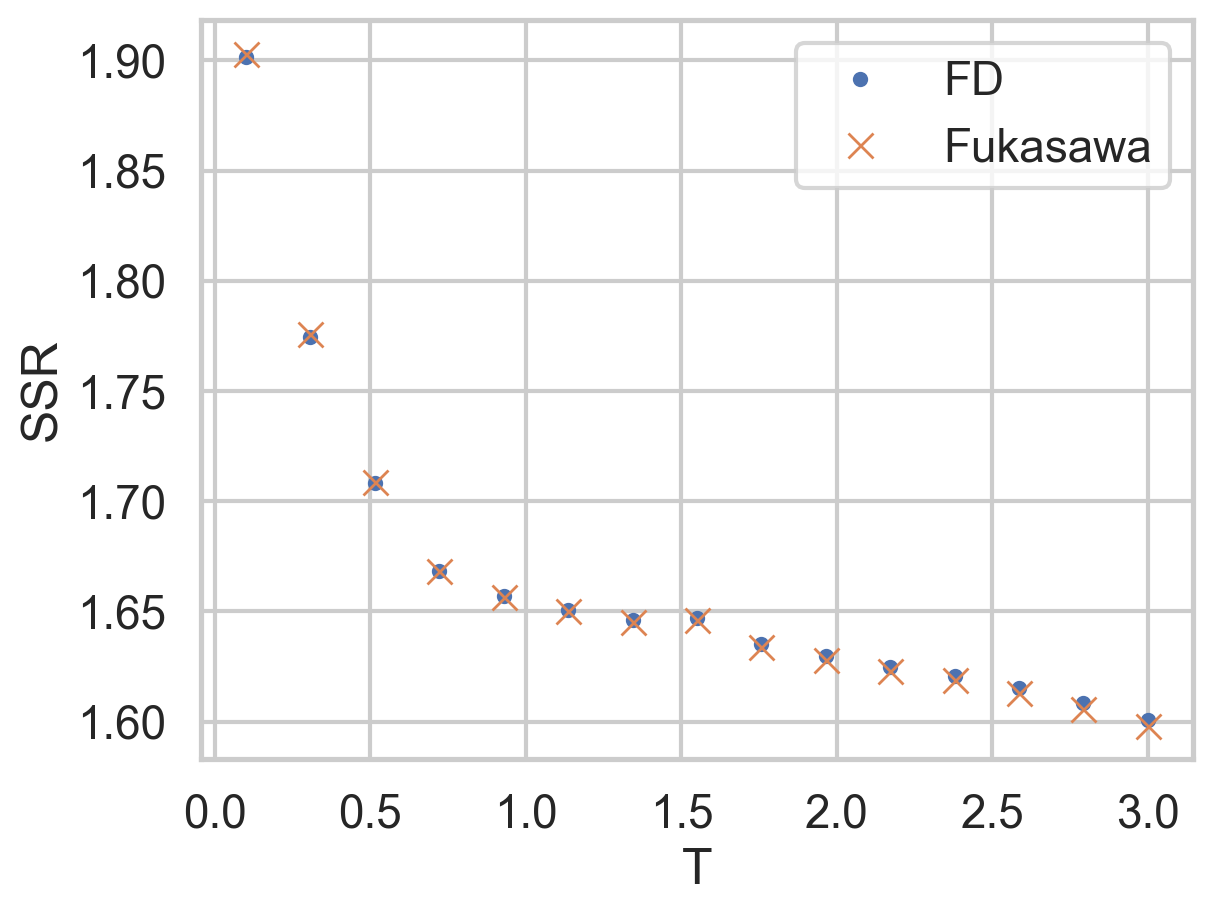

In [ ]:
fig, ax = plt.subplots()
# FD
ax.plot(
    Ts,
    ssr_fd["ssr_fd"],
    ".",
    label="FD",
)
# Fukasawa
ax.plot(
    Ts,
    ssr_fukasawa["ssr_fukasawa"],
    "x",
    label="Fukasawa",
)
# confidence intervals
if N_BATCH > 1:
    ax.fill_between(
        Ts, ssr_fd["ssr_fd_low"], ssr_fd["ssr_fd_high"], color="k", alpha=0.1
    )
    ax.fill_between(
        Ts,
        ssr_fukasawa["ssr_fukasawa_low"],
        ssr_fukasawa["ssr_fukasawa_high"],
        color="r",
        alpha=0.1,
    )
ax.set_xlabel("T")
ax.set_ylabel("SSR")
ax.legend()
plt.show()

# Rough Bergomi

In [26]:
id = 1
params, xi0 = get_params_rough_bergomi(1)
n_disc = 300
params["H"] = 0.25
rbergomi = RoughBergomiModel(params=params, xi0=xi0)
rbergomi

RoughBergomiModel with parameters:
eta=1.9, H=0.25, rho=-0.9, s0=1.0

In [27]:
ssr_fd = rbergomi.ssr_all(
    T=Ts, n_mc=N_MC, n_disc=n_disc, eps_ssr=1e-4, n_quad=40, seed=SEED, n_batch=N_BATCH
)


Computing SSR:
----------------
Model: RoughBergomiModel
Parameters:
Maturity T:  [0.1        0.30714286 0.51428571 0.72142857 0.92857143 1.13571429
 1.34285714 1.55       1.75714286 1.96428571 2.17142857 2.37857143
 2.58571429 2.79285714 3.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Finite difference perturbation for SSR: 0.0001
Number of simulation loops: 1
Number of independent batches: 1

1/15: expiry 0.1000
2/15: expiry 0.3071
3/15: expiry 0.5143
4/15: expiry 0.7214
5/15: expiry 0.9286
6/15: expiry 1.1357
7/15: expiry 1.3429
8/15: expiry 1.5500
9/15: expiry 1.7571
10/15: expiry 1.9643
11/15: expiry 2.1714
12/15: expiry 2.3786
13/15: expiry 2.5857
14/15: expiry 2.7929
15/15: expiry 3.0000


In [28]:
ssr_fukasawa = rbergomi.ssr_fukasawa_all(
    T=Ts, n_mc=N_MC, n_disc=n_disc, seed=SEED, n_batch=N_BATCH
)


Computing Fukasawa SSR:
----------------
Model: RoughBergomiModel
Maturity T:  [0.1        0.30714286 0.51428571 0.72142857 0.92857143 1.13571429
 1.34285714 1.55       1.75714286 1.96428571 2.17142857 2.37857143
 2.58571429 2.79285714 3.        ]
Monte Carlo paths: 300000
Number of time steps: 300
Number of simulation loops: 1
Number of independent batches: 1

1/15: expiry 0.1000
2/15: expiry 0.3071
3/15: expiry 0.5143
4/15: expiry 0.7214
5/15: expiry 0.9286
6/15: expiry 1.1357
7/15: expiry 1.3429
8/15: expiry 1.5500
9/15: expiry 1.7571
10/15: expiry 1.9643
11/15: expiry 2.1714
12/15: expiry 2.3786
13/15: expiry 2.5857
14/15: expiry 2.7929
15/15: expiry 3.0000


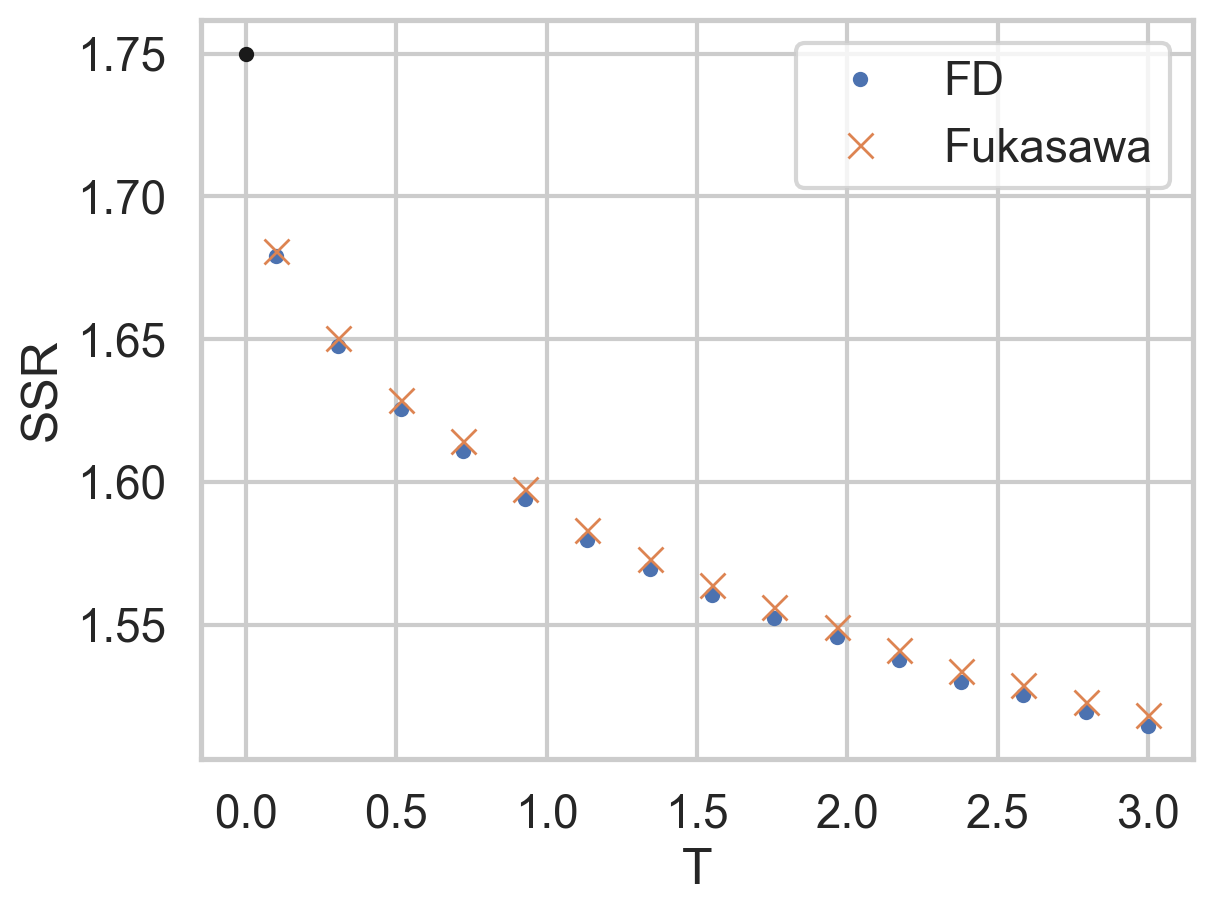

In [ ]:
fig, ax = plt.subplots()
# FD
ax.plot(
    Ts,
    ssr_fd["ssr_fd"],
    ".",
    label="FD",
)
# Fukasawa
ax.plot(
    Ts,
    ssr_fukasawa["ssr_fukasawa"],
    "x",
    label="Fukasawa",
)
ax.plot([0.0], [rbergomi.H + 1.5], ".k")
# confidence intervals
if N_BATCH > 1:
    ax.fill_between(
        Ts, ssr_fd["ssr_fd_low"], ssr_fd["ssr_fd_high"], color="k", alpha=0.1
    )
    ax.fill_between(
        Ts,
        ssr_fukasawa["ssr_fukasawa_low"],
        ssr_fukasawa["ssr_fukasawa_high"],
        color="k",
        alpha=0.1,
    )
ax.set_xlabel("T")
ax.set_ylabel("SSR")
ax.legend()
plt.show()